Ok, so I need to make an HR diagram. I should manually subdivide the target_table by spectral type inside this notebook instead of creating a bunch of separate files externally, or making the script itself do the separate plotting.

I've got to change this to be DR3 instead of eDR3

In [1]:

from __future__ import print_function


import matplotlib as mpl
#matplotlib.use('pdf')



import numpy as np
#from astroquery.gaia import Gaia
import astropy.units as u
import os
import sys
import astropy.coordinates as coord
from astropy.table import Table, QTable
import matplotlib.pyplot as plt
import scipy.stats as scistats
#import seaborn as sns
#import astropy

sys.path.append('../')
sys.path.append('/Users/BenKaiser/Desktop/radial_velocity_calculations/')

import time
start = time.time()


In [2]:
import cal_params as cp
import spec_plot_tools as spt

I do need to figure out how to get the Gaia scripts into my import path though because I'm not currently over there.... Maybe I should just move this over into the Gaia directory, externally? That's probably the easiest solution to this problem. I'm going to just move this jupyter notebook.

Ok, I have moved this into the Gaia directory and restarted the kernel. Now let's see if this import works...

In [3]:

#import passband_model_convolution as pmc
#import gaia_extinction
#import wdatmos
import plotting_dicts as pod

And import the actual script that does the plotting

In [4]:
import plot_alt_cmdDR3 as pac

Also need to import the panstarrs plotting code for later use

So, it did execute all of that crap like I expected, and it most likely assigned a bunch of variables that I'll now need to be careful of... actually those should have been assigned inside the script I imported, so it should be pac.variable, so I should be safe to do stuff

So the problem is the import never stops running. I added in the "if" statement that makes the plotting stuff only execute if the script is the main file called, so that should fix it. Now I'll restart the damn kernel again...

In [5]:
#target_input ='20190516B_retargeted_purple_search_gaia_scbd.csv'
#target_input ='20190516B_retargeted_purple_search_gaia_scbd_20201102_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20210616_update.csv'
#target_input ='20190516B_retargeted_purple_search_gaia_scbd_20210109_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20210824_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20211117_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20220106_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20220106_update_ps2_phot_added.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20220503_update_ps1_phot_added.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20220804_update.csv'
#target_input='20190516B_retargeted_purple_search_gaia_scbd_20230131_update.csv'
target_input='20190516B_retargeted_purple_search_gaia_scbd_20230301_update.csv'
figure_output_dir='/Users/BenKaiser/Desktop/'


In [6]:
input_path='/Users/BenKaiser/Desktop/MORDOR_Survey_paper/MORDOR_Survey_forPaper/Goodman_spectra_copy/'
input_file='full_MORDOR_survey_1681141339_fullphotometry_fitparams_massadd.csv'
input_table=Table.read(input_path+input_file)
output_path='/Users/BenKaiser/Desktop/'

In [7]:
target_table = input_table


Ok, I need to make this generate a nice litte BP-RP H-R diagram with Nicola's cuts drawn onto it.

(21172,)
/Users/BenKaiser/Desktop/gaia/mordor_survey_code
/Users/BenKaiser/Desktop
1751506394.698099


/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:15: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  from ipykernel import kernelapp as app


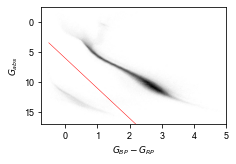

In [8]:
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(9.5,9.67), constrained_layout=True)
#plt.figure(figsize=(6.5,9.67/9.5*6.5), constrained_layout=False)
spt.start_mnras_fig(width_cols=1)


pac.plot_bkg_cmd(colours=['bp','rp'])
pac.plot_nicola_eDR3_cuts()
plt.ylabel(r'$G_{{abs}}$')
plt.xlabel(r'$G_{BP} - G_{RP}$')
plt.ylim(17,-2.5)
plt.xlim(-0.75,5)
plt.subplots_adjust(wspace = 0, hspace = 0, top = 0.90, bottom = 0.10, left = 0.12, right = 0.90)
#plt.legend()
print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig("HR_diagram_"+time_string+'.pdf')#plt.grid(True)

plt.show()


#plt.show()

Ay oh! It worked! Now onto the division by group. I need to check what the column name is... And I'll probably need to reimpose it onto the CSV again...

In [9]:
#sub_vals= np.where(target_table['good_obs']== 1)
#sub_vals=np.where(target_table['gf19']=='TRUE')

In [10]:
#sub_table= target_table[sub_vals]
#I no longer want some spinoff table that I made for no apparent reason
sub_table=target_table

In [11]:
dz= np.where(sub_table['sp_type']=='DZ')

In [12]:
print(sub_table[dz])
print('rows=',len(sub_table[dz]))
num_dz=len(sub_table[dz])

     name               designation              dr2_source_id    ... log_q note
------------- ------------------------------- ------------------- ... ----- ----
WD J1644-0449 b'Gaia DR2 4353607450860305024' 4353607450860305024 ... -4.37 none
 WD J2356-209 b'Gaia DR2 2341622358827194880' 2341622358827194880 ... -5.25    0
rows= 2


In [13]:
wddm= np.where(sub_table['sp_type']=='WDdM')

In [14]:
print(sub_table[wddm])
print('rows=',len(sub_table[wddm]))
num_wddm=len(sub_table[wddm])

       name                 designation           ... log_q note
----------------- ------------------------------- ... ----- ----
MORDOR J0110-5600 b'Gaia DR2 4913565903725184640' ...    --  0.0
MORDOR J0126-4707 b'Gaia DR2 4930805868092016256' ...    --  0.0
  SDSS J0132+1823 b'Gaia DR2 2593774421282488832' ...    --  0.0
MORDOR J0349+1241   b'Gaia DR2 37101100029189376' ...    --  0.0
MORDOR J0419-0745 b'Gaia DR2 3192967924382400256' ...    --  0.0
MORDOR J0424-2001 b'Gaia DR2 5091988397208440448' ...    --  0.0
 WISEA J0615-1247 b'Gaia DR2 3000597125173673088' ...    --  0.0
MORDOR J0706-4246 b'Gaia DR2 5559594371631444736' ...    --  0.0
MORDOR J0746-7004 b'Gaia DR2 5270620145795842432' ...    --  0.0
  SDSS J0824+2705  b'Gaia DR2 683016588814929280' ...    --  0.0
  SDSS J1129+2357 b'Gaia DR2 3992722441561708288' ...    --  0.0
  SDSS J1159+1039 b'Gaia DR2 3918451500552407552' ...    --  0.0
MORDOR J1357-1901 b'Gaia DR2 6290856877832637568' ...    --  0.0
  SDSS J1555+1330 b'Gaia 

In [15]:
dc= np.where(sub_table['sp_type']=='DC')

In [16]:
print(sub_table[dc])
print('rows=',len(sub_table[dc]))
num_dc=len(sub_table[dc])

       name       ...
----------------- ...
MORDOR J0008-2404 ...
  SDSS J0049+2244 ...
MORDOR J0110-5926 ...
MORDOR J0135-6306 ...
  LSPM J0211+0835 ...
MORDOR J0225-3312 ...
MORDOR J0248-1556 ...
  LSPM J0253+2135 ...
MORDOR J0325+1236 ...
MORDOR J0341-1029 ...
              ... ...
MORDOR J1801+1806 ...
MORDOR J1822+2319 ...
MORDOR J1926-5708 ...
MORDOR J1951-4909 ...
MORDOR J1956-2648 ...
MORDOR J2002-3337 ...
MORDOR J2238-5558 ...
  SDSS J2309+0959 ...
  SDSS J2314+2717 ...
MORDOR J2320-6637 ...
MORDOR J2324-5942 ...
Length = 53 rows
rows= 53


In [17]:
dqpec=np.where(sub_table['sp_type']=='DQpec')

In [18]:
print(sub_table[dqpec])
print('rows=',len(sub_table[dqpec]))
num_dqpec=len(sub_table[dqpec])

       name                 designation           ... log_q note
----------------- ------------------------------- ... ----- ----
       LEHPM 1774 b'Gaia DR2 5140433498003756160' ...    --  0.0
MORDOR J0334-6348 b'Gaia DR2 4673772519470806144' ...    --  0.0
MORDOR J2053+1302 b'Gaia DR2 1761085712628042112' ...    --  0.0
MORDOR J2236-3635 b'Gaia DR2 6596688068617463808' ...    --  0.0
rows= 4


In [19]:
unknown=np.where(sub_table['sp_type']=='??')
print(sub_table[unknown])
print('rows=',len(sub_table[unknown]))
num_unknown=len(sub_table[unknown])

       name                 designation           ... log_q note
----------------- ------------------------------- ... ----- ----
MORDOR J0253-3334 b'Gaia DR2 5051990775531173120' ...    --  0.0
MORDOR J0329-4306 b'Gaia DR2 4849260661232437504' ...    --  0.0
MORDOR J0548-5340 b'Gaia DR2 4768125052520236032' ...    --  0.0
MORDOR J0609-1736 b'Gaia DR2 2943040474599473024' ...    --  0.0
MORDOR J0628-3602 b'Gaia DR2 5581206101598276992' ...    --  0.0
MORDOR J1301-2722 b'Gaia DR2 6187146135032473344' ...    --  0.0
MORDOR J2114-1218 b'Gaia DR2 6891929583743053696' ...    --  0.0
MORDOR J2126-7502 b'Gaia DR2 6368907055055475968' ...    --  0.0
rows= 8


In [20]:
len(sub_table)

120

In [21]:
sub_table.pprint()

       name       ...
----------------- ...
MORDOR J0008-2404 ...
  SDSS J0049+2244 ...
MORDOR J0110-5926 ...
MORDOR J0110-5600 ...
MORDOR J0126-4707 ...
  SDSS J0132+1823 ...
MORDOR J0135-6306 ...
       LEHPM 1774 ...
  LSPM J0211+0835 ...
MORDOR J0225-3312 ...
              ... ...
MORDOR J2126-7502 ...
MORDOR J2158+4243 ...
MORDOR J2236-3635 ...
MORDOR J2238-5558 ...
MORDOR J2244+4204 ...
  SDSS J2309+0959 ...
  SDSS J2314+2717 ...
MORDOR J2320-6637 ...
MORDOR J2324-5942 ...
MORDOR J2339+3728 ...
     WD J2356-209 ...
Length = 120 rows


In [22]:
#for row in sub_table:
#    print(row['sp_type'])

In [23]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
#colours= ['g', 'rp']
colours= ['bp', 'rp']

<Figure size 720x360 with 0 Axes>

(21172,)


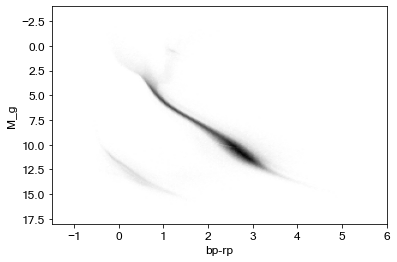

In [24]:
pac.plot_bkg_cmd(colours=colours)

g_calc-g_measured 0.0009991685018775343 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845275695617886 
rp_calc - rp_measured 0.014023587411202243 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.401591824899178
1.598408175100822 15.64199684062283
MORDOR J0008-2404
g_calc-g_measured 0.0009983054346420772 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845775746484378 
rp_calc - rp_measured 0.014024336336028398 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.707160768841497
1.2928392311585029 15.239996394036854
SDSS J0049+2244
g_calc-g_measured 0.0009997792494651492 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845470940284542 
rp_calc - rp_measured 0.014024372223190085 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
targ

g_calc-g_measured 0.0009996222449615288 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012846320742198714 
rp_calc - rp_measured 0.014024217953842566 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.9572878978219954
1.0427121021780046 14.827963458721968
MORDOR J0748-5022
g_calc-g_measured 0.0009982159295560677 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845819727818508 
rp_calc - rp_measured 0.014023648937254052 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.7858763155375605
1.2141236844624395 15.438054575113881
ULAS J0815+2427
g_calc-g_measured 0.000999803766227103 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845474316815597 
rp_calc - rp_measured 0.014023905001835146 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
t

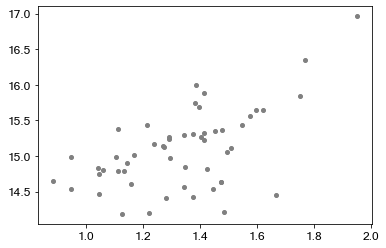

In [25]:
pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey')

g_calc-g_measured 0.0009991870273395875 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012846875803642632 
rp_calc - rp_measured 0.014024230297614793 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.515968843141433
1.484031156858567 16.035896787738942
WD J1644-0449
g_calc-g_measured 0.0009989851400931116 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012846235490929558 
rp_calc - rp_measured 0.014024040850525665 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.1657571968390883
1.8342428031609117 15.865250232450457
WD J2356-209


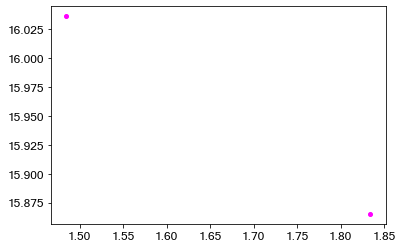

In [26]:
pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta')

g_calc-g_measured 0.0009993863957227234 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012846816535237338 
rp_calc - rp_measured 0.014024278939160695 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.7489191616226734
1.2510808383773266 14.748324866670554
MORDOR J0110-5600
g_calc-g_measured 0.0009991419727484185 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845781816928081 
rp_calc - rp_measured 0.014025248465799223 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -2.4644210437973086
2.5355789562026914 14.319129560023715
MORDOR J0126-4707
g_calc-g_measured 0.0009994062394618197 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.01284565208479549 
rp_calc - rp_measured 0.014023653481871179 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False

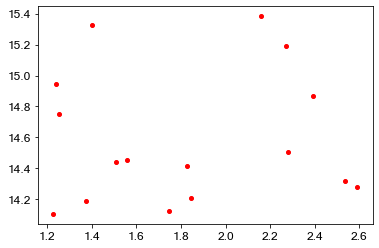

In [27]:
pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r')

g_calc-g_measured 0.0009980553665442926 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845852376244693 
rp_calc - rp_measured 0.01402497179407547 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.3871482814051355
1.6128517185948645 15.691642466485614
LEHPM 1774
g_calc-g_measured 0.0009986202592244808 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845516015747904 
rp_calc - rp_measured 0.014025242152172268 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.4629373860485337
1.5370626139514663 15.320933053751553
MORDOR J0334-6348
g_calc-g_measured 0.000998587991716704 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012846289890667606 
rp_calc - rp_measured 0.014023897144603836 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_

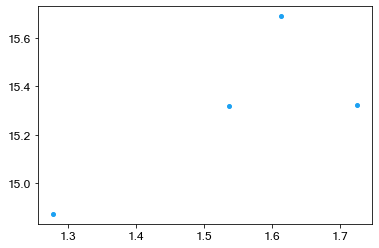

In [28]:
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2')

Text(0, 0.5, '$M_{G}$')

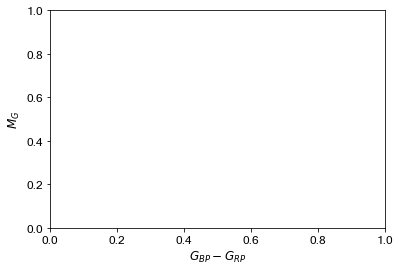

In [29]:
#plt.xlabel(r'$G-G_{RP}$')
plt.xlabel(r'$G_{BP}-G_{RP}$')
plt.ylabel(r'$M_{G}$')
#plt.xlim(-0.5, 2)

In [30]:
plt.show()

## BP-RP H-R diagram

(21172,)
g_calc-g_measured 0.0009991685018775343 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845275695617886 
rp_calc - rp_measured 0.014023587411202243 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.401591824899178
1.598408175100822 15.64199684062283
MORDOR J0008-2404
g_calc-g_measured 0.0009983054346420772 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845775746484378 
rp_calc - rp_measured 0.014024336336028398 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.707160768841497
1.2928392311585029 15.239996394036854
SDSS J0049+2244
g_calc-g_measured 0.0009997792494651492 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845470940284542 
rp_calc - rp_measured 0.014024372223190085 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False F

1.2204458780251386 14.1984615175273
MORDOR J1159+0035
g_calc-g_measured 0.0009985202187721143 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.01284592794818451 
rp_calc - rp_measured 0.01402476995250268 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.72937021773674
1.27062978226326 15.145260233640315
MORDOR J1202-0412
g_calc-g_measured 0.000998194865083235 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845219902509086 
rp_calc - rp_measured 0.014023653268420588 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.5843197602702084
1.4156802397297916 15.219622607055925
MORDOR J1309-1047
g_calc-g_measured 0.0009996410888106766 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845029529934493 
rp_calc - rp_measured 0.014023723987278913 
type(target_colour_dif) <class 'numpy.float64'>
tar

1.484031156858567 16.035896787738942
WD J1644-0449
g_calc-g_measured 0.0009989851400931116 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012846235490929558 
rp_calc - rp_measured 0.014024040850525665 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.1657571968390883
1.8342428031609117 15.865250232450457
WD J2356-209
g_calc-g_measured 0.0009993863957227234 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012846816535237338 
rp_calc - rp_measured 0.014024278939160695 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.7489191616226734
1.2510808383773266 14.748324866670554
MORDOR J0110-5600
g_calc-g_measured 0.0009991419727484185 
index_length 10000
mag_dist.shape (10000,)
bp_calc-bp_measured 0.012845781816928081 
rp_calc - rp_measured 0.014025248465799223 
type(target_colour_dif) <class 'numpy.float64'>
targ

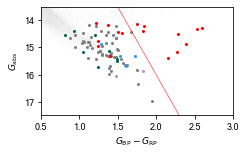

In [31]:
#plt.rc('font',size=12)
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(9.5,9.67), constrained_layout=False)
spt.start_mnras_fig(width_cols=1)

#colours= ['g', 'rp']
colours= ['bp', 'rp']
pac.plot_bkg_cmd(colours=colours)

#pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey',markersize=cp.plot_marker_size)
#pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta',markersize=cp.plot_marker_size)
#pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r',markersize=cp.plot_marker_size)
#pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2',markersize=cp.plot_marker_size)

pac.plot_target_table(sub_table[dc], colours=colours, list_color=cp.sp_type_colors['DC'],label='DC',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[unknown], colours=colours, list_color=cp.sp_type_colors['??'],label='Unknown',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[dz], colours=colours, list_color= cp.sp_type_colors['DZ'],label='DZ',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[wddm],colours=colours, list_color=cp.sp_type_colors['WDdM'],label='WD+dM',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  cp.sp_type_colors['DQpec'],label='DQpec',markersize=cp.hrd_plot_marker_size)

pac.plot_nicola_eDR3_cuts()


#plt.xlabel(r'$G-G_{RP}$')

plt.xlabel(r'$G_{\rm{BP}}-G_{\rm{RP}}$')
#plt.ylabel(r'$M_{G}$')
plt.ylabel(r'$G_{\rm{abs}}$')

#plt.legend()

#plt.xlim(0.5, 1.5)
#plt.ylim(17.5,12.5)

#plt.ylim(17,-1.5)
#plt.xlim(-0.75,5)
plt.ylim(17.5,13.5)
plt.xlim(0.5,3)

print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
plt.savefig("HR_diagram_DR3_GentileFusillo2021_"+time_string+'.pdf')#plt.grid(True)

plt.show()




In [32]:
plt.show()

In [33]:
parallax = sub_table['parallax']+pac.parallax_correction
parallax = parallax*1e-3
distance = 1./parallax
absmags=[]
#for row in sub_table:
    #this_abs, throw, garbage= pac.get_pass_abs_mag(target_table, plot_all=False, passband_string='g')
    #absmags.append(this_abs)

In [34]:
print(len(sub_table[dz]))
print(len(sub_table[dqpec]))
print(len(sub_table[dc]))
print(len(sub_table[wddm]))
print(len(sub_table))

2
4
53
16
120


## G-RP H-R diagram

(20504,)
g_calc-g_measured 0.0009991685018775343 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009991685018775343 
rp_calc - rp_measured 0.014023587411202243 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.345814793665184
0.6541852063348159 15.64199684062283
MORDOR J0008-2404
g_calc-g_measured 0.0009983054346420772 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009983054346420772 
rp_calc - rp_measured 0.014024336336028398 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.213518889788105
0.7864811102118949 15.239996394036854
SDSS J0049+2244
g_calc-g_measured 0.0009997792494651492 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009997792494651492 
rp_calc - rp_measured 0.014024372223190085 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False 

g_calc-bp_measured 0.0009984092386936538 
rp_calc - rp_measured 0.014024008684629052 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.937761622395154
1.0622383776048459 16.348463884889167
MORDOR J0445-6245
g_calc-g_measured 0.0009995903068045209 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009995903068045209 
rp_calc - rp_measured 0.014024018902905055 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.229426482429108
0.7705735175708917 14.640422048236287
SDSS J0447+2430
g_calc-g_measured 0.0009986650895399407 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009986650895399407 
rp_calc - rp_measured 0.014025417029639442 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.170779742662756
0.8292202573372442 14.683911011864403
MORDOR J0

g_calc-bp_measured 0.000998990353181739 
rp_calc - rp_measured 0.014024027182365728 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.208835354822348
0.791164645177652 15.410879843781931
MORDOR J1301-2722
g_calc-g_measured 0.000998194865083235 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.000998194865083235 
rp_calc - rp_measured 0.014023653268420588 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.011337454863298
0.9886625451367017 15.219622607055925
MORDOR J1309-1047
g_calc-g_measured 0.0009979230241512482 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009979230241512482 
rp_calc - rp_measured 0.014025341129176638 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.219526517836471
0.7804734821635293 14.7775102428887
SDSS J1314+47

1.1410863810348388 14.504043518718593
MORDOR J1700+2713
g_calc-g_measured 0.00099850733106166 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.00099850733106166 
rp_calc - rp_measured 0.01402480579939791 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.247412742560133
0.7525872574398669 14.586314892228941
MORDOR J1712+8237
g_calc-g_measured 0.0009993058099624363 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009993058099624363 
rp_calc - rp_measured 0.014024222213286919 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.198800673239262
0.801199326760738 15.604655452977038
MORDOR J1727+5420
g_calc-g_measured 0.000999671298099969 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.000999671298099969 
rp_calc - rp_measured 0.014024709699512528 
type(target_colour_dif) <class 'numpy.float64'>
targ

g_calc-g_measured 0.0009982742048961768 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009982742048961768 
rp_calc - rp_measured 0.014024886909030698 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.075330155794955
0.9246698442050452 16.224357253624394
MORDOR J2158+4243
g_calc-g_measured 0.0009979585797736945 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009979585797736945 
rp_calc - rp_measured 0.0140250131622075 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.137487274919348
0.8625127250806521 14.871043254501183
MORDOR J2236-3635
g_calc-g_measured 0.0009984202722925772 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009984202722925772 
rp_calc - rp_measured 0.014024852934479526 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
ta

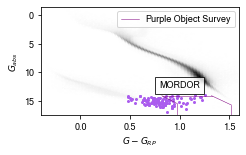

In [35]:
#plt.rc('font',size=12)
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(6.5,9.67/9.5*6.5), constrained_layout=False)
spt.start_mnras_fig(width_cols=1)
colours= ['g', 'rp']
#colours= ['bp', 'rp']
pac.plot_bkg_cmd(colours=colours)
pac.plot_target_table(target_table, colours=colours, list_color='#AB5DEE',markersize=cp.hrd_plot_marker_size,annotate=False)
#pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey')
#pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r')
#pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2')
#pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta')
#pac.plot_nicola_cuts()
pac.plot_ben_cuts()

plt.xlabel(r'$G-G_{RP}$')

#plt.xlabel(r'$G_{BP}-G_{RP}$')
#plt.ylabel(r'$M_{G}$')
plt.ylabel(r'$G_{abs}$')

plt.text(1.0,13.0,'MORDOR',verticalalignment='bottom',horizontalalignment='center',bbox=dict(facecolor='white',alpha=0.8))

#plt.legend()

#plt.xlim(0.5, 1.5)
#plt.ylim(17.5,12.5)

plt.ylim(17.5,-1.5)
#plt.xlim(-0.4,2.0)
plt.xlim(-0.4,1.6)


print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig("HR_diagram_GRP_"+time_string+'.pdf')#plt.grid(True)

plt.show()





## Zoomed in G-RP H-R diagram

(20504,)
g_calc-g_measured 0.0009991685018775343 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009991685018775343 
rp_calc - rp_measured 0.014023587411202243 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.345814793665184
0.6541852063348159 15.64199684062283
MORDOR J0008-2404
g_calc-g_measured 0.0009983054346420772 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009983054346420772 
rp_calc - rp_measured 0.014024336336028398 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.213518889788105
0.7864811102118949 15.239996394036854
SDSS J0049+2244
g_calc-g_measured 0.0009997792494651492 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009997792494651492 
rp_calc - rp_measured 0.014024372223190085 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False 

type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.201327461401142
0.7986725385988578 14.450183841653473
MORDOR J1534-0935
g_calc-g_measured 0.0009990724597912504 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009990724597912504 
rp_calc - rp_measured 0.014024810674118982 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.195049740289523
0.804950259710477 15.99374838933452
SDSS J1536+1718
g_calc-g_measured 0.000999019016248326 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.000999019016248326 
rp_calc - rp_measured 0.014023566796204534 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.933873394215503
1.066126605784497 15.441193860387992
MORDOR J1801+1806
g_calc-g_measured 0.0009989533694003683 
index_length 10000
mag_dist.shape (10000,

g_calc-bp_measured 0.0009979959119874593 
rp_calc - rp_measured 0.014023920422012282 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.082235977000259
0.9177640229997408 14.126202173176798
MORDOR J1357-1901
g_calc-g_measured 0.0009996949861168503 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009996949861168503 
rp_calc - rp_measured 0.01402424905877453 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.147004351435939
0.8529956485640611 14.444505728031451
SDSS J1555+1330
g_calc-g_measured 0.0009992214801783916 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.0009992214801783916 
rp_calc - rp_measured 0.014025162943863023 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.792816819759583
1.207183180240417 14.282942405200558
WISEA J1615

TypeError: plot_ben_cuts() got an unexpected keyword argument 'show_name'

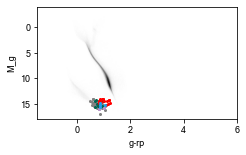

In [36]:
#plt.rc('font',size=12)
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(9.5,6), constrained_layout=False)
#plt.figure(figsize=(6.5,6/9.5*6.5), constrained_layout=True)
spt.start_mnras_fig(width_cols=1)

colours= ['g', 'rp']
#colours= ['bp', 'rp']
pac.plot_bkg_cmd(colours=colours)
#pac.plot_target_table(target_table, colours=colours, list_color='#AB5DEE',markersize=6,annotate=False)
#pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey',label='DC-'+str(num_dc))
#pac.plot_target_table(sub_table[unknown], colours=colours, list_color='#006652',label='Unknown-'+str(num_unknown))
#pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta',label='DZ-'+str(num_dz))
#pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r',label='WD+dM-'+str(num_wddm))
#pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2',label='DQpec-'+str(num_dqpec))
pac.plot_target_table(sub_table[dc], colours=colours, list_color=cp.sp_type_colors['DC'],label='DC',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[unknown], colours=colours, list_color=cp.sp_type_colors['??'],label='Unknown',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[dz], colours=colours, list_color= cp.sp_type_colors['DZ'],label='DZ',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[wddm],colours=colours, list_color=cp.sp_type_colors['WDdM'],label='WD+dM',markersize=cp.hrd_plot_marker_size)
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  cp.sp_type_colors['DQpec'],label='DQpec',markersize=cp.hrd_plot_marker_size)

#pac.plot_nicola_cuts()
pac.plot_ben_cuts(show_name=False)

plt.xlabel(r'$G-G_{RP}$')

#plt.xlabel(r'$G_{BP}-G_{RP}$')
#plt.ylabel(r'$M_{G}$')
plt.ylabel(r'$G_{abs}$')


#plt.legend()

#plt.xlim(0.4, 1.8)
plt.xlim(0.3, 1.7)

plt.ylim(17.5,13.5)

#plt.ylim(17,-1.5)
#plt.xlim(-0.4,2.0)
plt.legend(loc='lower left')

print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig("HR_diagram_GRP_zoomed"+time_string+'.pdf')#plt.grid(True)

plt.show()






In [ ]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
#colours= ['bp', 'rp']
colours= ['g', 'rp']
pac.plot_bkg_cmd(colours=colours)
#pac.plot_nicola_cuts()
pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey', label='DC')
pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r', label='WD+dM')
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2', label='DQpec')
pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta', label='DZ')
plt.xlabel(r'$G-G_{RP}$')
#plt.xlabel(r'$G_{BP}-G_{RP}$')
plt.ylabel(r'$M_{G}$')

#plt.xlim(-0.5, 1.5)
#plt.ylim(17.5,7.5)

plt.xlim(-0.4, 2.0)
#plt.xlim(0,4)
plt.ylim(17.5,10)



plt.legend()
plt.legend(loc='lower left')



In [ ]:
plt.show()

In [ ]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
colours= ['bp', 'rp']
#colours= ['g', 'rp']
pac.plot_bkg_cmd(colours=colours)
pac.plot_nicola_cuts()
pac.plot_target_table(sub_table[dc], colours=colours, list_color='grey', label='DC')
pac.plot_target_table(sub_table[wddm],colours=colours, list_color='r', label='WD+dM')
pac.plot_target_table(sub_table[dqpec],colours=colours, list_color=  '#1ca1f2', label='DQpec')
pac.plot_target_table(sub_table[dz], colours=colours, list_color= 'magenta', label='DZ')
#plt.xlabel(r'$G-G_{RP}$')
plt.xlabel(r'$G_{BP}-G_{RP}$')
plt.ylabel(r'$M_{G}$')

#plt.xlim(-0.5, 1.5)
#plt.ylim(17.5,7.5)

#plt.xlim(-0.25, 1.5)
plt.xlim(0,4)
plt.ylim(17.5,10)



plt.legend()
#plt.legend(loc='lower left')
plt.legend(loc='upper right')






In [ ]:
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92

2021-06-16 updated version counts:

2

4

26

12

120

## PanSTARRS-2 Color-Color diagrams (2022-05-02)

import the panstarrs plotting code I wrote externally earlier

In [ ]:
plt.show()

In [ ]:
#plt.rc('font',size=12)
plt.rc('font',family='Microsoft Sans Serif',size=18)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
plt.figure(figsize=(9.5,6), constrained_layout=False)

#c1c2='g-r'
#c3c4='r-i'

c1c2='g-y'
c3c4='r-i'



pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table,color=  'k',label='Obj. w/out spectrum')
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dc],color='grey',label='DC-'+str(num_dc))
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[unknown], color='#006652',label='??-'+str(num_unknown))
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dz], color= 'magenta',label='DZ-'+str(num_dz))
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[wddm],color='r',label='WD+dM-'+str(num_wddm))
pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dqpec],color=  '#1ca1f2',label='DQpec-'+str(num_dqpec))





#pac.plot_nicola_cuts()
#pac.plot_ben_cuts()

#plt.xlabel(r'$G-G_{RP}$')

#plt.xlabel(r'$G_{BP}-G_{RP}$')
#plt.ylabel(r'$M_{G}$')
#plt.legend()

#plt.xlim(0.4, 1.8)
#plt.ylim(17.5,13.5)

#plt.ylim(17,-1.5)
#plt.xlim(-0.4,2.0)
plt.legend(loc='best',fontsize=16)

print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig(c3c4+'_vs_'+c1c2+'_'+time_string+'.pdf')#plt.grid(True)

plt.show()



#plt.rc('font',size=12)
plt.rc('font',family='Microsoft Sans Serif',size=18)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
plt.figure(figsize=(9.5,6), constrained_layout=False)

c1c2='g-r'
c3c4='r-i'

color_list=['g','r','i','z','y']

for color1 in color_list:
    for color2 in color_list:
        c1c2=color1+'-'+color2
        print(c1c2)
        if color1 != color2:
            for color3 in color_list:
                for color4 in color_list:
                    c3c4=color3+'-'+color4
                    print(c3c4)
                    if ((color3 != color4) and (c1c2 != c3c4)):
                        #do the plotting
                        print('should be plotting')

                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dc],color='grey',label='DC-'+str(num_dc))
                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[unknown], color='#006652',label='??-'+str(num_unknown))
                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dz], color= 'magenta',label='DZ-'+str(num_dz))
                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[wddm],color='r',label='WD+dM-'+str(num_wddm))
                        pps2.plot_colors(c1c2=c1c2, c3c4=c3c4,input_table=sub_table[dqpec],color=  '#1ca1f2',label='DQpec-'+str(num_dqpec))




                        #pac.plot_nicola_cuts()
                        #pac.plot_ben_cuts()

                        #plt.xlabel(r'$G-G_{RP}$')

                        #plt.xlabel(r'$G_{BP}-G_{RP}$')
                        #plt.ylabel(r'$M_{G}$')
                        #plt.legend()

                        #plt.xlim(0.4, 1.8)
                        #plt.ylim(17.5,13.5)

                        #plt.ylim(17,-1.5)
                        #plt.xlim(-0.4,2.0)
                        plt.legend(loc='best',fontsize=16)

                        print(os.getcwd())
                        os.chdir(figure_output_dir)
                        print(os.getcwd())
                        start = time.time()
                        print(start)
                        time_string=str(start).split('.')[0]
                        plt.savefig(c3c4+'_vs_'+c1c2+'_'+time_string+'.pdf')#plt.grid(True)

                        plt.show()


                    else:
                        pass
        else:
            pass

In [ ]:
(2+50+16+5)/83.